# Heart Disease Analysis

### 1. Understanding the Problem Statement

### 2. Data Collection and Dataset Information

### 3. Data Checks and Validation

### 4. Exploratory Data Analysis (EDA)

### 5. Data Preprocessing

### 6. Feature Selection and Engineering

### 7. Model Training

### 8. Model Evaluation

### 9. Model Comparison and Best Model Selection

### 10. Conclusion

### 1. Problem statement

- The goal of this project is to analyze how patient demographic and clinical variables such as age, sex, and vital health indicators are associated with the presence of heart disease.

### 2. Data Collection and Dataset Information

- Dataset source - https://doi.org/10.6084/m9.figshare.20236848
- The data consists of 14 attributes and 303 instances

#### 2.1 Import Data and Required Packages

##### Importing Pandas, Numpy, Matplotlib, Seaborn and Warnings Library

In [1]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt
%matplotlib inline
import warnings 
warnings.filterwarnings('ignore')

##### Importing Data as Pandas DataFrame

In [61]:
df=pd.read_csv("data/processed.cleveland.data", header=None)

columns = [
    "age", "sex", "cp", "trestbps", "chol", "fbs",
    "restecg", "thalach", "exang", "oldpeak",
    "slp", "ca", "thal", "output"
]

df.columns = columns


#### 2.2 Dataset Information

- age: age in years
- sex: 1 = male, 0 = female
- cp: chest pain type  
    - 0 = typical angina  
    - 1 = atypical angina  
    - 2 = non-anginal pain  
    - 3 = asymptomatic

- trtbps: resting blood pressure (mmHg)
- chol: serum cholesterol (mg/dL)
- fbs: fasting blood pressure > 120 mg/dL (1 = true, 0 = false)
- restecg: resting electrocardiogram results
    - 0 = normal
    - 1 = ST-T wave adnormality
    - 2 = probable/definite left ventricular hypertrophy
- thalach: maximum heart rate achieved during exercise
- exng: exercise induced angina (1 = yes, 0 = no)
- oldpeak: ST depression induced by exercise relative to rest
- slp: slope of the peak exercise ST segment
    - 1 = upsloping
    - 2 = flat
    - 3 = downsloping 
- ca: number of major vessels colored by fluoroscopy (0–3)
- thal: thalassemia / blood flow defect test
    - 0 = normal
    - 1 = fixed defect
    - 2 = reversible defect
    - 3 = unknown/other 
- output: presence of heart disease (1 = disease present, 0 = no disease)



### 3. Data Checks and Validation

- Dataset Shape
- Data Types
- Missing Values
- Duplicate Records
- Unique Value Analysis
- Statistical Summary
- Class Balance Check


#### 3.1 Dataset shape

In [49]:
df.shape

(303, 14)

#### 3.2 Data types

In [50]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        303 non-null    str    
 12  thal      303 non-null    str    
 13  target    303 non-null    int64  
dtypes: float64(11), int64(1), str(2)
memory usage: 33.3 KB


#### 3.3 Missing values

In [51]:
df.replace("?", np.nan, inplace=True)

df.isna().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

In [64]:
df.dropna(inplace=True)

Missing values dropped from dataset

#### 3.4 Duplicate records

In [67]:
df.duplicated().sum()

np.int64(0)

#### 3.5 Unique value analysis

In [62]:
df.nunique()

age          41
sex           2
cp            4
trestbps     50
chol        152
fbs           2
restecg       3
thalach      91
exang         2
oldpeak      40
slp           3
ca            5
thal          4
output        5
dtype: int64

#### 3.6 Statistical summary

In [63]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slp,output
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.937294
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,1.228536
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,4.000000


#### 3.7 Class balance check

In [17]:
df['output'].value_counts(normalize=True)

output
1    0.570934
0    0.429066
Name: proportion, dtype: float64

### 4. Exploratory Data Analysis

#### 4.1 Target Variable Distribution

<Axes: xlabel='Output', ylabel='count'>

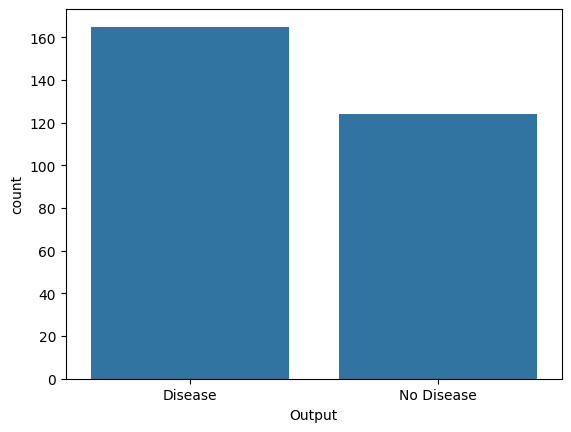

In [28]:
df['Output'] = df['output'].map({0: 'No Disease', 1: 'Disease'})
sns.countplot(x='Output', data=df)

#### 4.2 Gender vs Output

<Axes: xlabel='Sex', ylabel='count'>

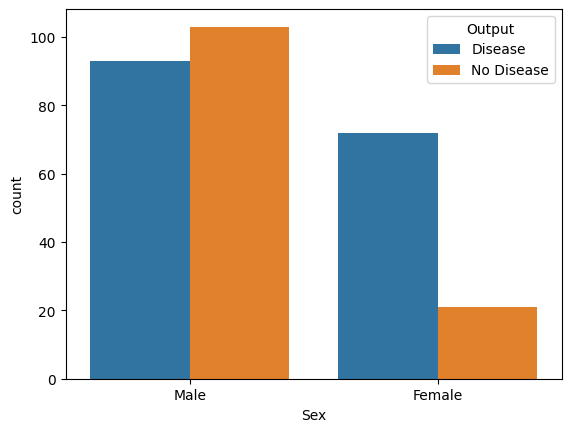

In [33]:
df['Sex'] = df['sex'].map({0: 'Female', 1: 'Male'})
sns.countplot(x='Sex', hue='Output', data=df)

#### 4.3 Age Distribution

<Axes: xlabel='age', ylabel='Count'>

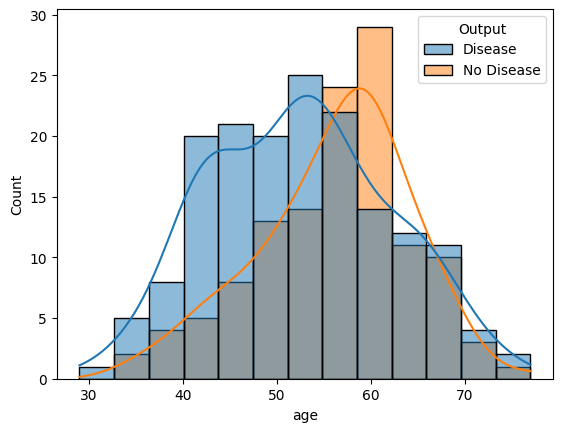

In [34]:
sns.histplot(data=df,x='age',kde=True,hue='Output')

#### 4.4 Chest Pain Type vs Heart Disease

#### 4.5 Maximum Heart Rate vs Age

#### 4.6 Cholesterol Distribution vs Output

#### 4.7 Blood Pressure vs Output

#### 4.8 Correlation Heat Map

#### 4.9 ST Depression vs Output

#### 4.10 Feature Comparison Grid

#### 4.8 Correlation Heat Map